In [23]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [24]:
data = pd.read_csv('HOUSEPRICE.csv')
df = data.copy()

df['Area'] = pd.to_numeric(df['Area'], errors = "coerce")

df = df[ df['Area'] < 200 ]
df = df[ df['Area'] > 50 ]

df['Parking'] = df['Parking'].astype(int)
df['Warehouse'] = df['Warehouse'].astype(int)
df['Elevator'] = df['Elevator'].astype(int)

df = pd.get_dummies(df, columns = ['Address'], drop_first = True, dtype = int)

df = df.reset_index(drop = True)

df.head()

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD),Address_Abbasabad,Address_Abuzar,Address_Afsarieh,...,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
0,63.0,1,1,1,1,1.850000e+09,61666.67,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,60.0,1,1,1,1,1.850000e+09,61666.67,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,79.0,2,1,1,1,5.500000e+08,18333.33,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,95.0,2,1,1,1,9.025000e+08,30083.33,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,123.0,2,1,1,1,7.000000e+09,233333.33,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
x = df.drop( ['Price(USD)', 'Price'], axis = 1 )
y = df[[ 'Price(USD)' ]]


from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 7)

y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

scaler = StandardScaler()

x_normalize_train = scaler.fit_transform(x_train)
x_normalize_test = scaler.transform(x_test)

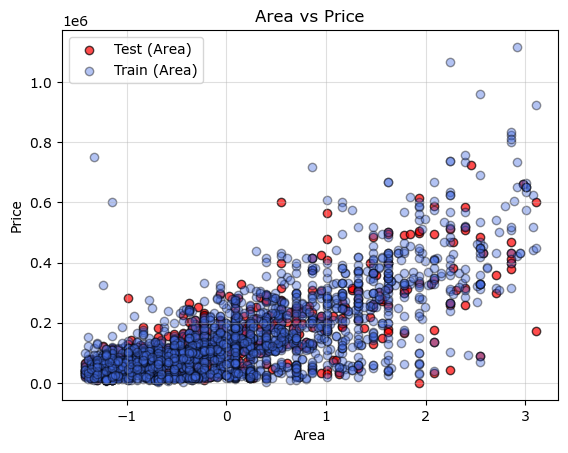

In [26]:
plt.scatter(x_normalize_test[:, 0], y_test, color = 'r', edgecolor = 'k', label = 'Test (Area)', alpha = 0.7)
plt.scatter(x_normalize_train[:, 0], y_train, color = 'royalblue', edgecolor = 'k', label = 'Train (Area)', alpha = 0.4)

plt.xlabel('Area')
plt.ylabel('Price')

plt.title('Area vs Price')

plt.grid(True, alpha = 0.4)

plt.legend()

In [27]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()

regr.fit(x_normalize_train, y_train_log)

y_pred = regr.predict(x_normalize_test)

In [28]:
print()
print(f"Intercept: {regr.intercept_[0]}")
print()

count = 0
for i in regr.coef_[0] :
    print(f"Coefficient {count}: {regr.coef_[0][count]}")
    count += 1

print()


Intercept: 11.408116113025905

Coefficient 0: 0.39801466446229605
Coefficient 1: 0.0005081623070732899
Coefficient 2: 0.056212132875208404
Coefficient 3: -0.010831893920619128
Coefficient 4: 0.03844748581181759
Coefficient 5: 0.007273469748161926
Coefficient 6: 0.0021965831870095357
Coefficient 7: -0.006679451184268277
Coefficient 8: -0.007022650160778902
Coefficient 9: 0.010529206866545099
Coefficient 10: 0.026223449485490075
Coefficient 11: -0.01888883219985088
Coefficient 12: -0.015534339596954536
Coefficient 13: 0.020753121659045998
Coefficient 14: 0.012151634335148015
Coefficient 15: -0.01241273731362684
Coefficient 16: -0.10185066437056065
Coefficient 17: 0.0575308883208078
Coefficient 18: 0.019189289266957704
Coefficient 19: -0.016086150204874923
Coefficient 20: 0.006087489543079333
Coefficient 21: -0.00999620788035007
Coefficient 22: -0.0037314615525293887
Coefficient 23: -0.047792837229099494
Coefficient 24: -0.006502412583733463
Coefficient 25: -0.014679672687014741
Coeffici

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print()
print(f"1) R2-SCORE: {r2_score(y_test, np.exp(y_pred)):1.3f}")
print(f"2) RMSE: {np.sqrt(mean_squared_error(y_test, np.exp(y_pred))):1.0f}")
print(f"3) MAE: {mean_absolute_error(y_test, np.exp(y_pred)):1.0f}")
print()


1) R2-SCORE: 0.850
2) RMSE: 46962
3) MAE: 26355



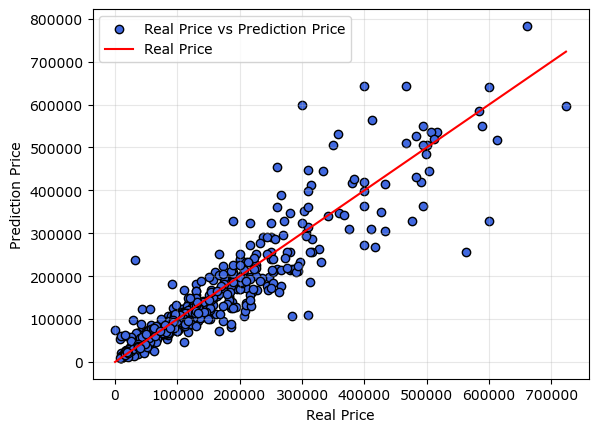

In [30]:
plt.scatter(y_test, np.exp(y_pred), label = 'Real Price vs Prediction Price', edgecolor = 'k', color = 'royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', label = 'Real Price')

plt.grid(True, alpha = 0.3)

plt.xlabel('Real Price')
plt.ylabel('Prediction Price')

plt.legend()

In [ ]:
wlc = print("-> Pleas enter your home information: (Elevator | Area | Location | Warehouse | Room | Parking) ")

try:
    elv = input("Elevator: ").strip()
    area = input("Area:  ").strip()
    loc = input("Location: ").strip()
    room = input("Room: ").strip()
    parking = input("Parking: ").strip()
    wh = input("Warehouse: ").strip()
    
except Exception as ex :
    print('Error! -> ', ex)


try:
    x_user = pd.DataFrame([{
    
        'Area': area,
        'Room': room,
        'Parking': parking,
        'Warehouse': wh,
        'Elevator': elv,
        'Address': loc
    
                       }])
    
except Exception as ex :
    print('Error! -> ', ex)
    
try:
    new_home = pd.get_dummies(x_user, columns = ['Address'], drop_first = True, dtype = int)
    new_home = new_home.reindex(columns = x_train.columns, fill_value = 0)
    
except Exception as ex :
    print('Error! -> ', ex)

try:
    x_user_normalize = scaler.transform(new_home)

except Exception as ex :
    print('Error! -> ', ex)

try:
    price = np.exp(regr.predict(x_user_normalize)[0][0])
    print(f"Price: {price:1.0f}")
    
except Exception as ex :
    print('Error! -> ', ex)

-> Pleas enter your home information: (Elevator | Area | Location | Warehouse | Room | Parking) 
